In [6]:
import joblib 
import shap
import pandas as pd
import numpy as np

final_lgb = joblib.load("../models/lightgbm_final.joblib")
print("Model loaded. Best iteration:", final_lgb.best_iteration_)

Model loaded. Best iteration: 273


In [7]:
train = pd.read_csv("../data/processed/train.csv")
val = pd.read_csv("../data/processed/val.csv")

CAT_COLS = ["main_category", "sub_category", "sub_sub_category", "condition_label"]
NUM_COLS = ["item_condition_id", "shipping", "category_depth", "name_length",
            "desc_length", "name_word_count", "has_description", "is_branded",
            "cat_avg_price", "brand_avg_price"]

for c in CAT_COLS:
    train[c] = train[c].fillna("missing").astype("category")
    val[c] = val[c].fillna("missing").astype(pd.CategoricalDtype(categories=train[c].cat.categories))

X_val = val[NUM_COLS + CAT_COLS]
print("X_val shape:", X_val.shape)

X_val shape: (9945, 14)


C:\Users\hp\AppData\Local\Temp\ipykernel_2412\11563354.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  val[c] = val[c].fillna("missing").astype(pd.CategoricalDtype(categories=train[c].cat.categories))
C:\Users\hp\AppData\Local\Temp\ipykernel_2412\11563354.py:11: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  val[c] = val[c].fillna("missing").astype(pd.CategoricalDtype(categories=train[c].cat.categories))


In [8]:
explainer = shap.TreeExplainer(final_lgb)
shap_values = explainer.shap_values(X_val)

print("SHAP values shape:", shap_values.shape)
print("Baseline (expected value):", explainer.expected_value)

# Verify the additive property ourselves, for one row
row0_reconstructed = explainer.expected_value + shap_values[0].sum()
row0_actual = final_lgb.predict(X_val.iloc[[0]])[0]
print("Baseline + SHAP sum:", round(row0_reconstructed, 4))
print("Actual model prediction:", round(row0_actual, 4))

SHAP values shape: (9945, 14)
Baseline (expected value): 2.975827946636258
Baseline + SHAP sum: 3.0805
Actual model prediction: 3.0805


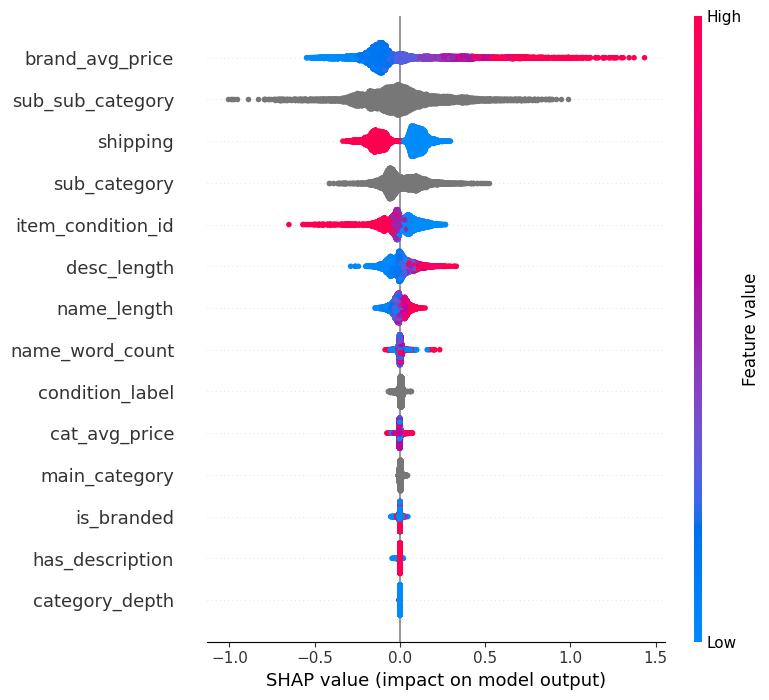

In [9]:
shap.summary_plot(shap_values, X_val)

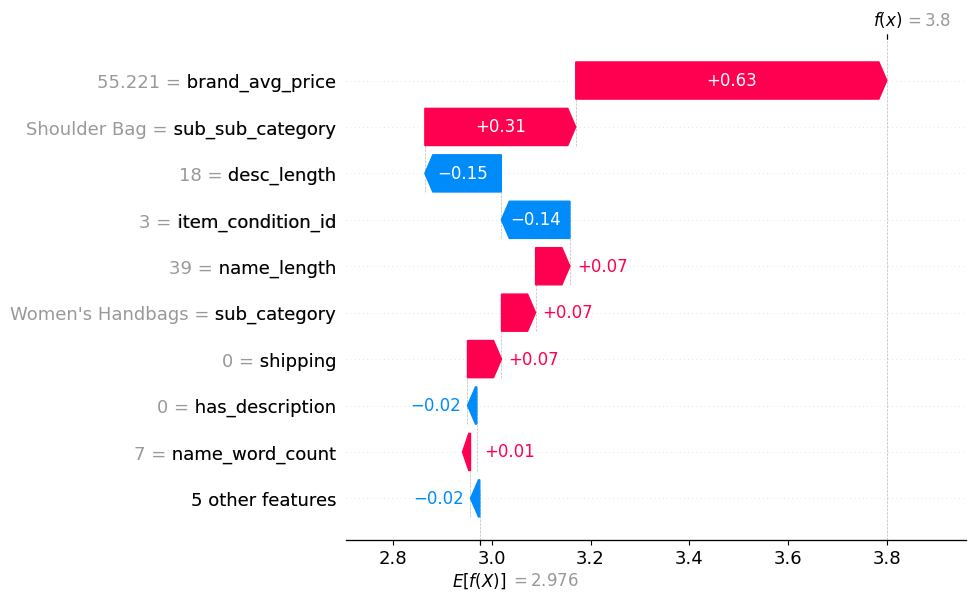

Actual price: $1506
Predicted price ($):  43.69


In [10]:
row_index = 8567  # Chanel Classic Flag Bag
row_pos = X_val.index.get_loc(row_index)

exp = shap.Explanation(
    values=shap_values[row_pos],
    base_values=explainer.expected_value,
    data=X_val.iloc[row_pos],
    feature_names=X_val.columns.tolist()
)
shap.plots.waterfall(exp)

print("Actual price: $1506")
print("Predicted price ($): ", round(np.expm1(explainer.expected_value + shap_values[row_pos].sum()), 2))

In [11]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_pct = 100 * mean_abs_shap / mean_abs_shap.sum()

importance_df = pd.DataFrame({
    "feature": X_val.columns,
    "importance_pct": importance_pct
}).sort_values("importance_pct", ascending=False)

print(importance_df.to_string(index=False))

print("\n--- Business narrative sentences ---")
for _, row in importance_df.head(5).iterrows():
    print(f"{row['feature']} explains {row['importance_pct']:.1f}% of the model's pricing decisions.")

          feature  importance_pct
  brand_avg_price       27.404844
 sub_sub_category       20.962700
         shipping       16.281713
     sub_category       10.662931
item_condition_id        9.730084
      desc_length        6.950133
      name_length        4.274801
  name_word_count        1.133551
  condition_label        0.942391
    cat_avg_price        0.815088
    main_category        0.432494
       is_branded        0.270183
  has_description        0.137704
   category_depth        0.001383

--- Business narrative sentences ---
brand_avg_price explains 27.4% of the model's pricing decisions.
sub_sub_category explains 21.0% of the model's pricing decisions.
shipping explains 16.3% of the model's pricing decisions.
sub_category explains 10.7% of the model's pricing decisions.
item_condition_id explains 9.7% of the model's pricing decisions.


In [12]:
def explain_listing_in_dollars(row_pos, top_n=3):
    base_price = np.expm1(explainer.expected_value)
    running_log = explainer.expected_value

    contributions = list(zip(X_val.columns, shap_values[row_pos]))
    contributions.sort(key=lambda x: abs(x[1]), reverse=True)

    print(f"Baseline price: ${base_price:.2f}")
    for feature, shap_val in contributions[:top_n]:
        new_log = running_log + shap_val
        dollar_effect = np.expm1(new_log) - np.expm1(running_log)
        direction = "added" if dollar_effect > 0 else "subtracted"
        print(f"  {feature} {direction} ${abs(dollar_effect):.2f}")
        running_log = new_log

    final_price = np.expm1(explainer.expected_value + sum(v for _, v in contributions))
    print(f"Final predicted price: ${final_price:.2f}")

explain_listing_in_dollars(row_pos=X_val.index.get_loc(8567), top_n=3)

Baseline price: $18.61
  brand_avg_price added $17.20
  sub_sub_category added $13.15
  desc_length subtracted $7.17
Final predicted price: $43.69


In [14]:
y_val = val["log_price"]
pred_final = final_lgb.predict(X_val)
rmsle_final = np.sqrt(((y_val - pred_final) ** 2).mean())
print("Final LightGBM val RMSLE:", round(rmsle_final, 4))
print("Trees used:", final_lgb.best_iteration_)

Final LightGBM val RMSLE: 0.5673
Trees used: 273
